=== Building Rust binary in release mode ===
Cargo build completed successfully.

Running for table_type=heap...
Running for table_type=partition...


,table_type,repair_type,idx,tx_id,tx_type,duration_ms,count,read_ts
0,heap,No Repair,0,0,Insert,165.876995,300000.0,NaN
1,heap,No Repair,1,1,Update,16.656641,30000.0,NaN
2,heap,No Repair,2,2,Update,15.647951,30000.0,NaN
3,heap,No Repair,3,3,Scan,145.548455,NaN,3.0
4,heap,No Repair,4,4,Scan,144.863846,NaN,3.0
...,...,...,...,...,...,...,...,...
61,partition,Write Repair,6,6,Update,269.693988,30000.0,NaN
62,partition,Write Repair,7,7,Update,291.780935,30000.0,NaN
63,partition,Write Repair,8,8,Scan,172.277744,NaN,3.0
64,partition,Write Repair,9,9,Scan,176.331420,NaN,9.0


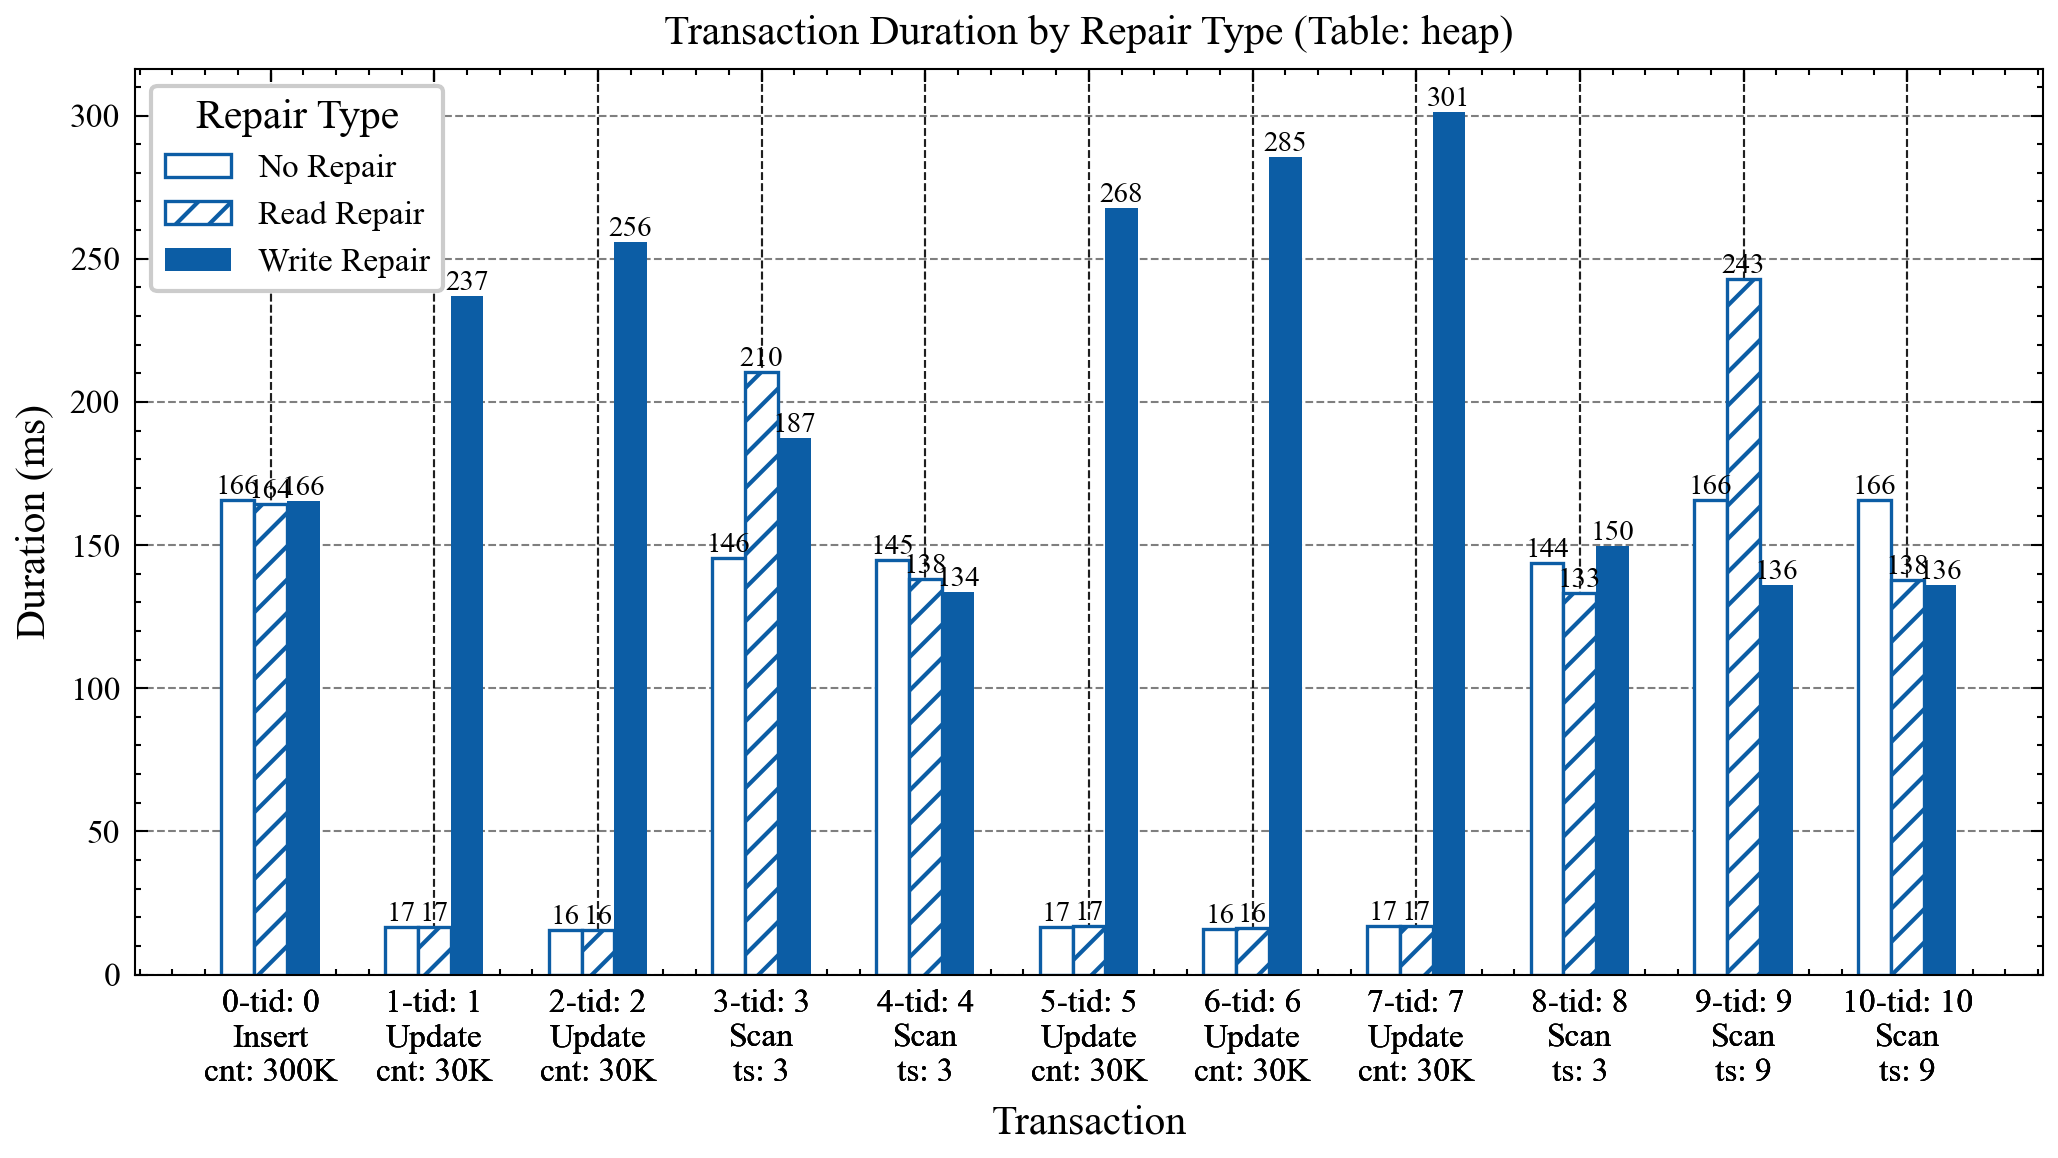

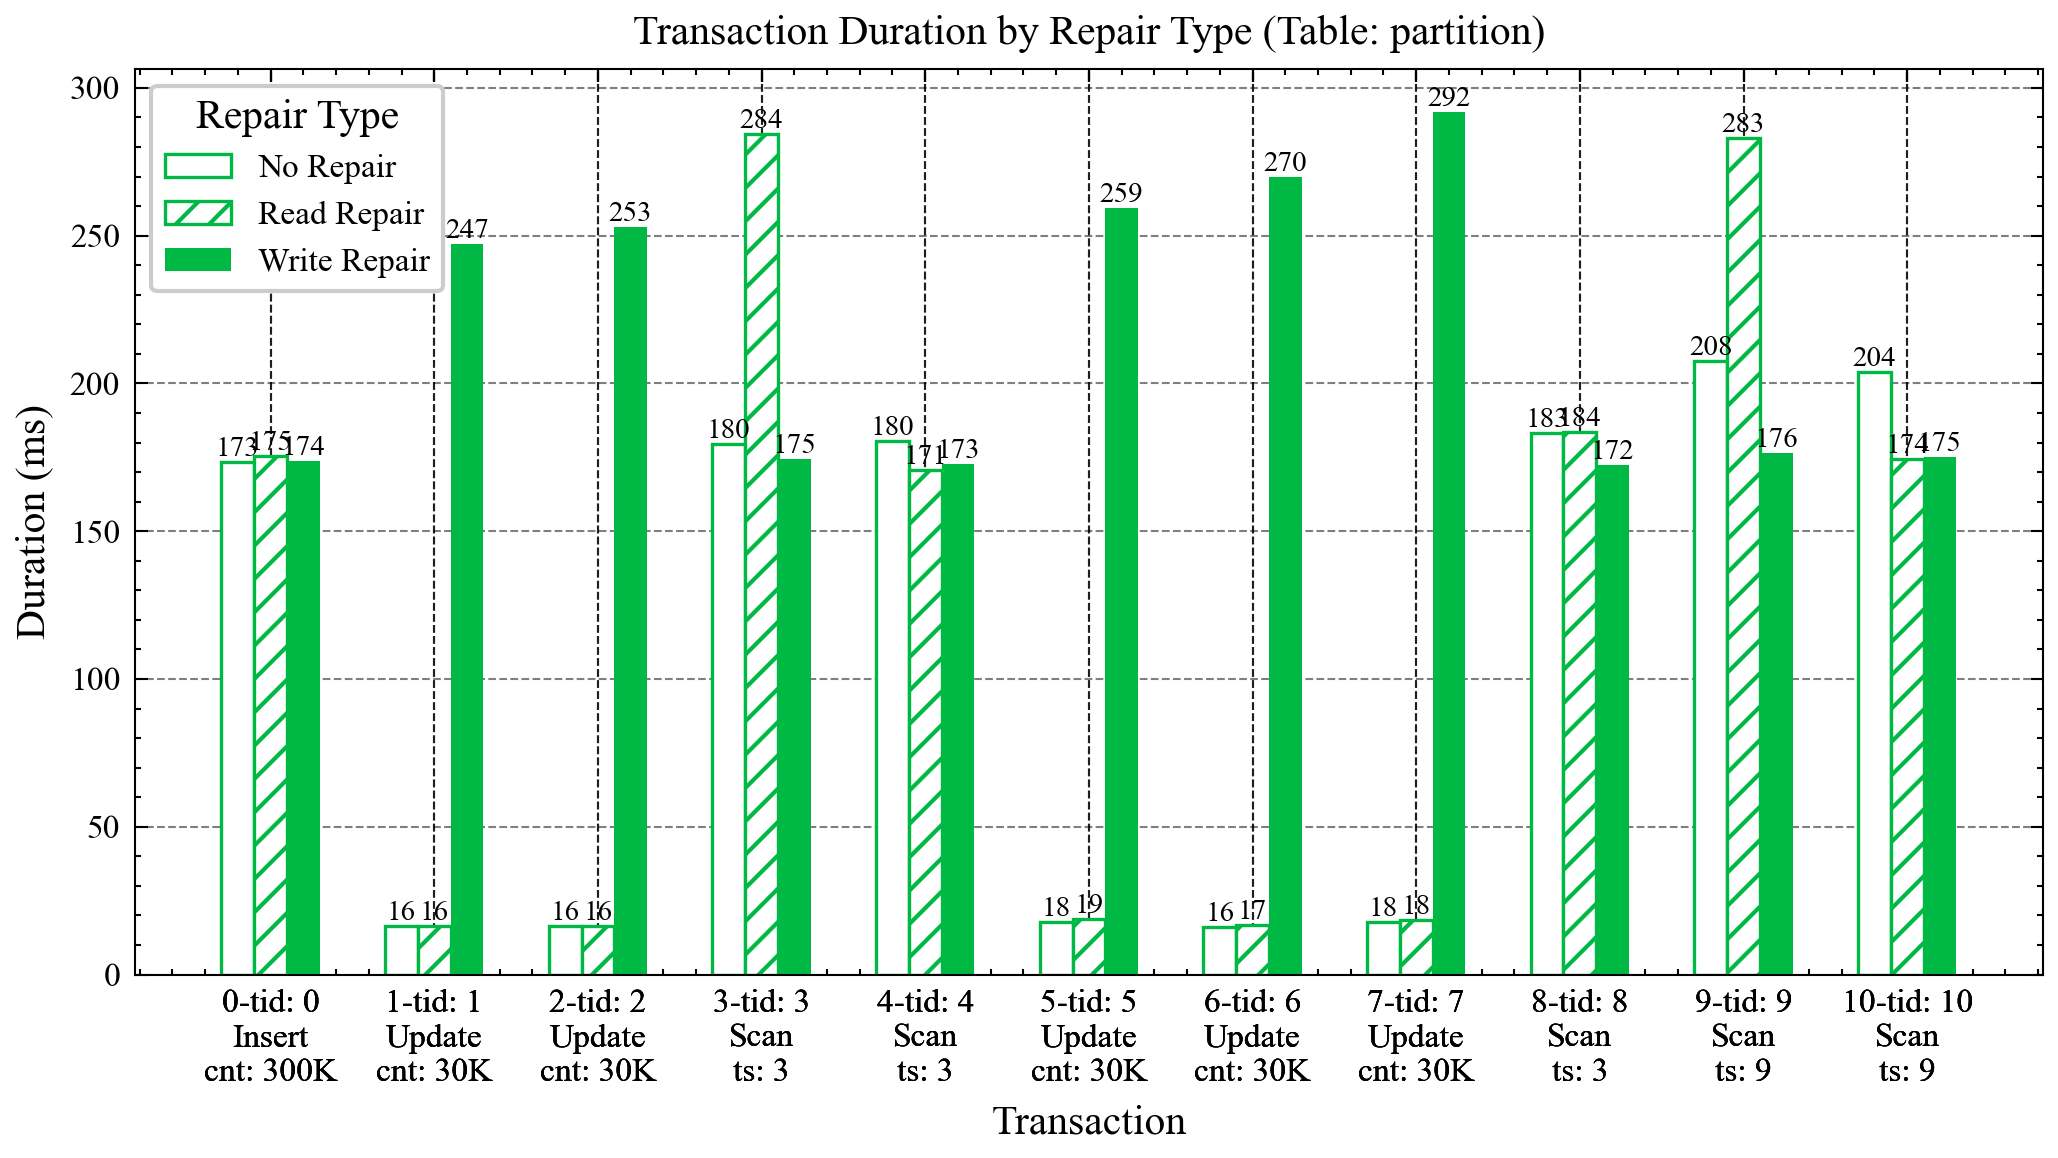

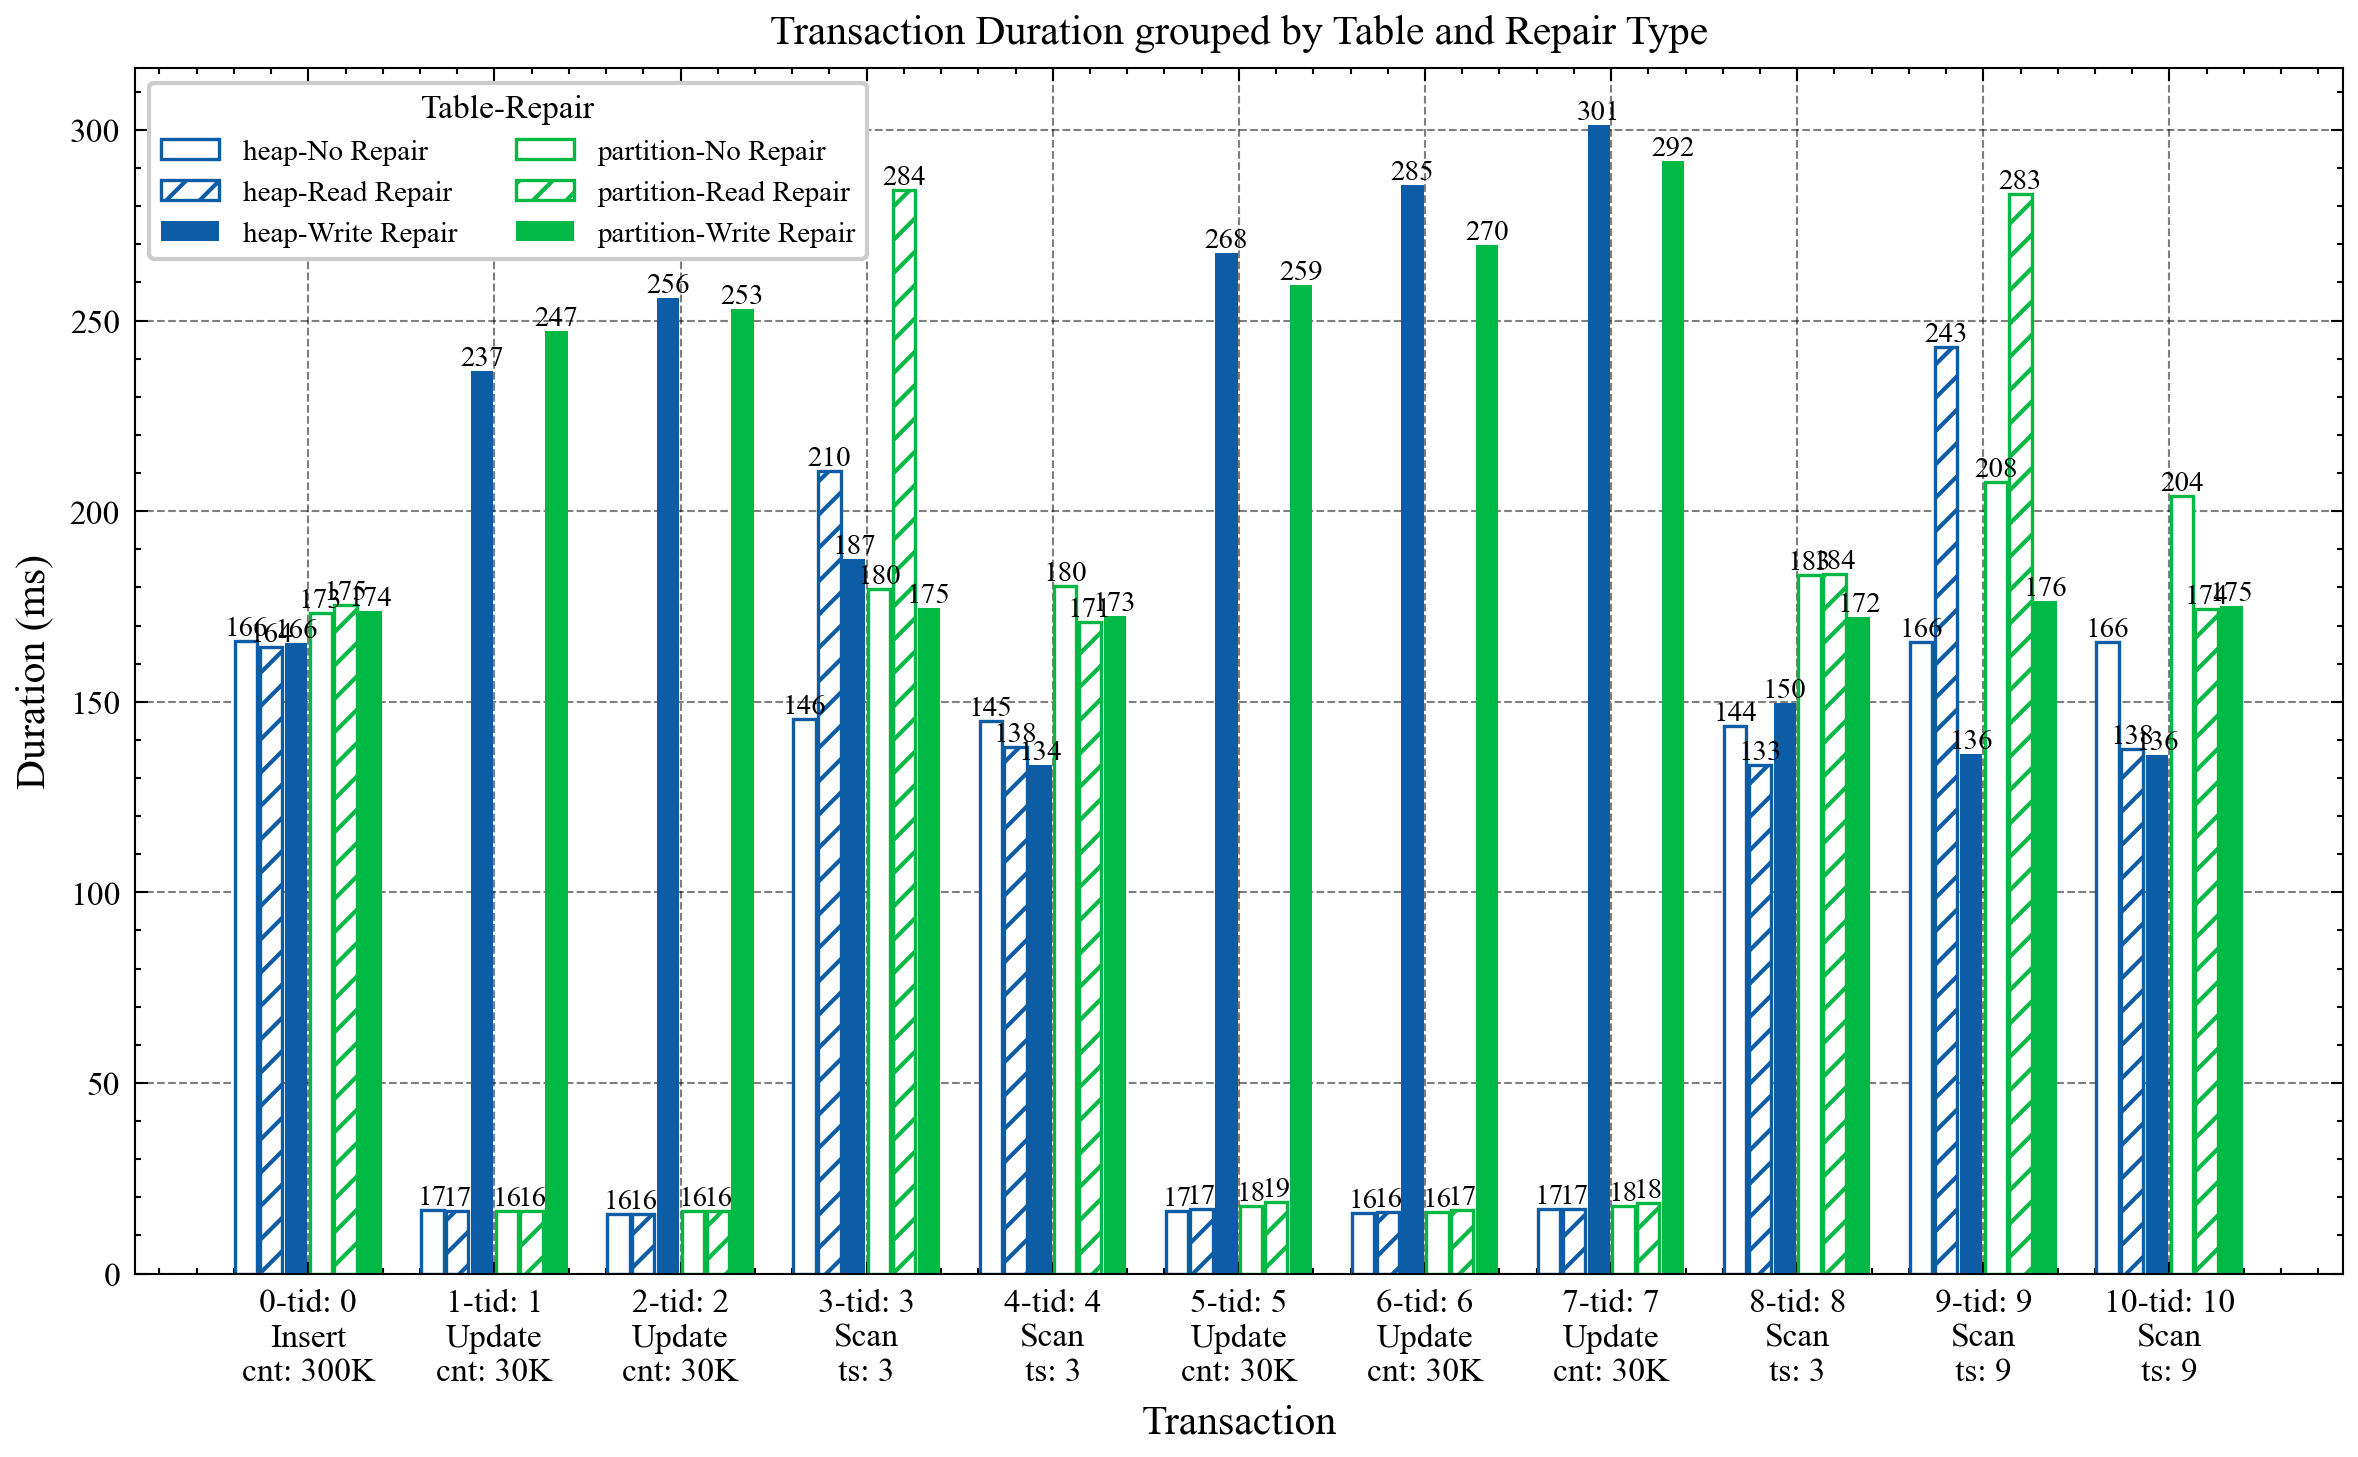

In [20]:
import subprocess
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import re

# ----------------------------------------
# Configuration
# ----------------------------------------

# Path to the join_repair binary
BIN = Path("../../../target/release/join_repair")
plt.style.use('../custom_plt_sytle.mplstyle')

# List of table types to test
TABLE_TYPES = ["heap", "partition"]

# Seed value
SEED = 15661183908140331744

print("=== Building Rust binary in release mode ===")
DEFAULT_BIN_NAME = "join_repair"
build_cmd = ["cargo", "build", "--release", "--bin", DEFAULT_BIN_NAME]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

# Base CLI arguments (excluding table-type, which will be added separately)
BASE_ARGS = [
    "--row-count", "300K",
    "--join-key-size", "100",
    "--pkey-size", "100",
    "--value-size", "800",
    "--num-tx", "10",
    "--write-tx-ratio", "0.7",
    "--update-tx-ratio", "1.0",
    "--update-count-ratio", "0.1",
    "--insert-tx-ratio", "0.0",
    "--insert-count-ratio", "0.1",
    "--delete-tx-ratio", "0.0",
    "--delete-count-ratio", "0.1",
    "--get-tx-ratio", "0.0",
    "--get-count-ratio", "0.1",
    "--read-tx-ratio", "0.3",
    "--scan-key-tx-ratio", "0.0",
    "--scan-all-tx-ratio", "1.0",
    "--delta-scan-tx-ratio", "0.0",
    # "--num-join-keys", "..."   # Optional
    # "--recent-get-ratio", "..."  # Optional
    # "--bucket-num", "..."        # Optional
    # "--seed", str(SEED),
]

MANUAL_TXS = "u,0.1 u,0.1 scan,3 scan,3 u,0.1 u,0.1 u,0.1 scan,3 scan,9 scan,9"
if MANUAL_TXS:
    BASE_ARGS += ["--manual-txs", MANUAL_TXS]

# ----------------------------------------
# Function to parse the output
# ----------------------------------------

def parse_result(log_text, table_type):
    """
    Parse the stdout from join_repair into a structured DataFrame.
    """
    data = []
    repair_type = None
    no_repair_run_count = 0

    for line in log_text.splitlines():
        line = line.strip()

        # Detect repair type
        if line.startswith("No Repair"):
            repair_type = "No Repair"
            no_repair_run_count += 1
            continue
        elif line.startswith("Read Repair"):
            repair_type = "Read Repair"
            continue
        elif line.startswith("Write Repair"):
            repair_type = "Write Repair"
            continue
        
        # Match lines with timing information
        match = re.match(r'\[(.*?)\]\s+idx:\s+(\d+),\s+tx_id:\s+(\d+),\s+tx_type:\s+(\w+),\s+duration:\s+([0-9\.]+)(ms|s|µs),(.*)', line)
        if match and repair_type:
            if repair_type == "No Repair" and no_repair_run_count == 1:
                # Skip the first No Repair run (cache warm-up)
                continue

            _, idx, tx_id, tx_type, duration_value, duration_unit, rest = match.groups()

            # Normalize duration to milliseconds
            duration_value = float(duration_value)
            if duration_unit == 's':
                duration_ms = duration_value * 1000
            elif duration_unit == 'ms':
                duration_ms = duration_value
            elif duration_unit == 'µs':
                duration_ms = duration_value / 1000
            else:
                raise ValueError(f"Unknown time unit: {duration_unit}")

            # Parse additional information (count or read_ts)
            count = None
            read_ts = None
            if 'Insert count' in rest or 'Update count' in rest:
                count_match = re.search(r'count:\s*(\d+)', rest)
                if count_match:
                    count = int(count_match.group(1))
            if 'read_ts' in rest:
                read_ts_match = re.search(r'read_ts:\s*(\d+)', rest)
                if read_ts_match:
                    read_ts = int(read_ts_match.group(1))

            data.append({
                'table_type': table_type,
                'repair_type': repair_type,
                'idx': int(idx),
                'tx_id': int(tx_id),
                'tx_type': tx_type,
                'duration_ms': duration_ms,
                'count': count,
                'read_ts': read_ts,
            })

    return pd.DataFrame(data)

# ----------------------------------------
# Function to run the binary and collect data
# ----------------------------------------

def run_and_collect(bin_path, table_types, base_args):
    """
    Execute join_repair binary for each table type and collect results.
    """
    all_dfs = []
    
    for table_type in table_types:
        print(f"Running for table_type={table_type}...")

        # Build command-line arguments
        args = [str(bin_path)] + base_args + ["--table-type", table_type]

        # Execute the binary
        result = subprocess.run(
            args,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            text=True
        )

        if result.returncode != 0:
            print(f"Error running join_repair for {table_type}:")
            print(result.stderr)
            continue
        
        # Parse the output
        df = parse_result(result.stdout, table_type)
        all_dfs.append(df)
    
    if all_dfs:
        # Concatenate all results into a single DataFrame
        final_df = pd.concat(all_dfs, ignore_index=True)
        return final_df
    else:
        return pd.DataFrame()

# ----------------------------------------
# Function to plot the results
# ----------------------------------------
def draw_bar_labels(ax, x_positions, heights, font_size=7):
    for x, y in zip(x_positions, heights):
        if y > 0:  # 0은 굳이 표시 안 함
            ax.text(
                x, 
                y, 
                f"{y:.0f}", 
                ha='center', 
                va='bottom', 
                fontsize=font_size
            )

def prepare_plot_data(df):
    prop_cycler = plt.rcParams['axes.prop_cycle']
    colors = prop_cycler.by_key()['color']

    table_types = sorted(df['table_type'].unique())
    color_map = {table_type: colors[i % len(colors)] for i, table_type in enumerate(table_types)}

    repair_hatches = {
        "Write Repair": "",
        "Read Repair": "///",
        "No Repair": "",
    }
    repair_types = ["No Repair", "Read Repair", "Write Repair"]

    unique_idx = sorted(df['idx'].unique())

    x_labels = []
    for idx in unique_idx:
        row = df[df['idx'] == idx].iloc[0]
        optional = ""
        if row['tx_type'] in ["Insert", "Update", "Delete", "Get"] and pd.notnull(row['count']):
            count = int(row['count'])
            if count >= 1_000_000:
                value = count / 1_000_000
                count_str = f"{value:.1f}".rstrip('0').rstrip('.') + "M"
            elif count >= 1_000:
                value = count / 1_000
                count_str = f"{value:.1f}".rstrip('0').rstrip('.') + "K"
            else:
                count_str = str(count)
            optional = f"cnt: {count_str}"
        elif row['tx_type'] in ["ScanKey", "Scan", "DeltaScan"] and pd.notnull(row['read_ts']):
            optional = f"ts: {int(row['read_ts'])}"
        label = f"{idx}-tid: {row['tx_id']}\n{row['tx_type']}\n{optional}"
        x_labels.append(label)

    return color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels

def prepare_bar_style(repair_type, table_type, color_map, repair_hatches):
    if repair_type == "Write Repair":
        return {
            'facecolor': color_map[table_type],
            'edgecolor': color_map[table_type],
            'hatch': '',
            'linewidth': 0
        }
    else:
        return {
            'facecolor': 'white',
            'edgecolor': color_map[table_type],
            'hatch': repair_hatches.get(repair_type, ''),
            'linewidth': 0.8
        }

def plot_result(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels = prepare_plot_data(df)

    for table_type in table_types:
        fig, ax = plt.subplots()

        width = 0.2
        offsets = [-width, 0, width]

        df_table = df[df['table_type'] == table_type].sort_values('idx')

        for i, repair_type in enumerate(repair_types):
            df_repair = df_table[df_table['repair_type'] == repair_type]

            style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

            ax.bar(
                df_repair['idx'] + offsets[i],
                df_repair['duration_ms'],
                width=width,
                label=repair_type,
                **style
            )

            draw_bar_labels(ax, df_repair['idx'] + offsets[i], df_repair['duration_ms'])

        ax.set_xticks(df_table['idx'])
        ax.set_xticklabels([x_labels[unique_idx.index(idx)] for idx in df_table['idx']], rotation=0, fontsize=8, ha='center')

        ax.set_xlabel('Transaction')
        ax.set_ylabel('Duration (ms)')
        ax.set_title(f"Transaction Duration by Repair Type (Table: {table_type})")

        ax.legend(title="Repair Type", loc="best")
        plt.tight_layout()
        plt.show()

def plot_all(df):
    color_map, repair_hatches, repair_types, table_types, unique_idx, x_labels = prepare_plot_data(df)

    fig, ax = plt.subplots(figsize=(max(8, len(unique_idx) * 0.5), 5))

    groups = [(table_type, repair_type) for table_type in table_types for repair_type in repair_types]
    num_bars_per_group = len(groups)
    group_width = 0.8
    bar_width = group_width / num_bars_per_group

    idx_to_pos = {idx: pos for pos, idx in enumerate(unique_idx)}

    for i, (table_type, repair_type) in enumerate(groups):
        df_group = df[(df['table_type'] == table_type) & (df['repair_type'] == repair_type)]

        x_positions = []
        durations = []

        for idx in unique_idx:
            x_pos = idx_to_pos[idx] + (i - num_bars_per_group/2) * bar_width + bar_width/2
            df_row = df_group[df_group['idx'] == idx]
            duration = df_row['duration_ms'].values[0] if not df_row.empty else 0
            x_positions.append(x_pos)
            durations.append(duration)

        style = prepare_bar_style(repair_type, table_type, color_map, repair_hatches)

        ax.bar(
            x_positions,
            durations,
            width=bar_width * 0.9,
            label=f"{table_type}-{repair_type}",
            **style
        )

        draw_bar_labels(ax, x_positions, durations)

    ax.set_xticks(range(len(unique_idx)))
    ax.set_xticklabels(x_labels, rotation=0, fontsize=8, ha='center')

    ax.set_xlabel('Transaction')
    ax.set_ylabel('Duration (ms)')
    ax.set_title('Transaction Duration grouped by Table and Repair Type')

    plt.grid(True, axis='y')

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title="Table-Repair", fontsize=7, title_fontsize=8, ncol=2)

    plt.tight_layout()
    plt.show()

# ----------------------------------------
# Main execution
# ----------------------------------------

# Run experiments and collect results
df = run_and_collect(BIN, TABLE_TYPES, BASE_ARGS)

# Display the resulting DataFrame
display(df)

# Plot per table type
plot_result(df)

# Plot one combined figure
plot_all(df)